In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, cross_validate

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Define Project Paths
# ============================================================

PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../models"
REPORT_DIR = "../reports"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

X_TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "X_train.csv"
)

X_TEST_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "X_test.csv"
)

Y_TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "y_train.csv"
)

Y_TEST_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "y_test.csv"
)

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "preprocessing_metadata.pkl"
)

print("Project paths configured successfully.")

Project paths configured successfully.


In [3]:
# ============================================================
# Load Processed Datasets
# ============================================================

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH)["Sales"]
y_test = pd.read_csv(Y_TEST_PATH)["Sales"]

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


In [4]:
# ============================================================
# Validate Dataset Shapes
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (160, 3)
X_test shape : (40, 3)
y_train shape: (160,)
y_test shape : (40,)


In [5]:
# ============================================================
# Validate Feature-Target Alignment
# ============================================================

assert len(X_train) == len(y_train), (
    "Training features and target are not aligned."
)

assert len(X_test) == len(y_test), (
    "Testing features and target are not aligned."
)

assert X_train.columns.tolist() == X_test.columns.tolist(), (
    "Training and testing feature columns do not match."
)

assert not X_train.isnull().any().any(), (
    "Missing values found in X_train."
)

assert not X_test.isnull().any().any(), (
    "Missing values found in X_test."
)

assert not y_train.isnull().any(), (
    "Missing values found in y_train."
)

assert not y_test.isnull().any(), (
    "Missing values found in y_test."
)

print("All dataset validation checks passed.")

All dataset validation checks passed.


In [6]:
# ============================================================
# Load Preprocessing Metadata
# ============================================================

if os.path.exists(METADATA_PATH):
    preprocessing_metadata = joblib.load(
        METADATA_PATH
    )

    print("Preprocessing metadata loaded.")
    display(preprocessing_metadata)
else:
    preprocessing_metadata = {
        "feature_columns": X_train.columns.tolist(),
        "target_column": "Sales",
        "random_state": 42
    }

    print(
        "Metadata file was not found. "
        "Metadata was reconstructed from the dataset."
    )

Preprocessing metadata loaded.


{'feature_columns': ['TV', 'Radio', 'Newspaper'],
 'target_column': 'Sales',
 'test_size': 0.2,
 'random_state': 42,
 'scaler': 'StandardScaler'}

In [7]:
# ============================================================
# Validate Feature Order
# ============================================================

expected_features = preprocessing_metadata[
    "feature_columns"
]

assert X_train.columns.tolist() == expected_features, (
    "Training feature order does not match metadata."
)

assert X_test.columns.tolist() == expected_features, (
    "Testing feature order does not match metadata."
)

print("Feature order validated successfully.")

Feature order validated successfully.


In [8]:
print("Training Features")
display(X_train.head())

print("Training Target")
display(y_train.head().to_frame())

print("Testing Features")
display(X_test.head())

Training Features


,TV,Radio,Newspaper
0,116.0,7.7,23.1
1,177.0,9.3,6.4
2,43.1,26.7,35.1
3,62.3,12.6,18.3
4,224.0,2.4,15.6


Training Target


,Sales
0,11.0
1,14.8
2,10.1
3,9.7
4,16.6


Testing Features


,TV,Radio,Newspaper
0,163.3,31.6,52.9
1,195.4,47.7,52.9
2,292.9,28.3,43.2
3,11.7,36.9,45.2
4,220.3,49.0,3.2


In [9]:
# ============================================================
# Regression Evaluation Function
# ============================================================

def calculate_regression_metrics(
    y_actual,
    y_predicted
):
    """
    Calculate common regression evaluation metrics.
    """

    r2 = r2_score(
        y_actual,
        y_predicted
    )

    mae = mean_absolute_error(
        y_actual,
        y_predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_predicted
        )
    )

    non_zero_mask = np.asarray(y_actual) != 0

    if non_zero_mask.any():
        actual_non_zero = np.asarray(
            y_actual
        )[non_zero_mask]

        predicted_non_zero = np.asarray(
            y_predicted
        )[non_zero_mask]

        mape = np.mean(
            np.abs(
                (
                    actual_non_zero
                    - predicted_non_zero
                )
                / actual_non_zero
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [10]:
# ============================================================
# Define Baseline Models
# ============================================================

RANDOM_STATE = 42

models = {
    "Linear Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]),

    "Ridge Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            )
        )
    ]),

    "Lasso Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            Lasso(
                alpha=0.01,
                max_iter=10000
            )
        )
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=None,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Baseline models defined successfully.")

Baseline models defined successfully.


In [11]:
# ============================================================
# Add XGBoost Model if Available
# ============================================================

xgboost_available = False

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgboost_available = True

    print("XGBoost added successfully.")

except ImportError:
    print(
        "XGBoost is not installed. "
        "The remaining models will still be trained."
    )

XGBoost added successfully.


In [12]:
# ============================================================
# Configure Cross-Validation
# ============================================================

cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

print("Cross-validation configured successfully.")

Cross-validation configured successfully.


In [13]:
# ============================================================
# Train, Cross-Validate, and Evaluate Models
# ============================================================

model_results = []
cross_validation_results = []
prediction_results = pd.DataFrame({
    "Actual_Sales": y_test
})

trained_models = {}

for model_name, model in models.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    model_start_time = time.perf_counter()

    # Cross-validation is performed only on the training data.
    cv_scores = cross_validate(
        estimator=clone(model),
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_r2_scores = cv_scores["test_r2"]
    cv_mae_scores = -cv_scores["test_mae"]
    cv_rmse_scores = np.sqrt(
        -cv_scores["test_mse"]
    )

    # Fit the model on the complete training set.
    fitted_model = clone(model)

    fitted_model.fit(
        X_train,
        y_train
    )

    train_predictions = fitted_model.predict(
        X_train
    )

    test_predictions = fitted_model.predict(
        X_test
    )

    training_metrics = calculate_regression_metrics(
        y_train,
        train_predictions
    )

    testing_metrics = calculate_regression_metrics(
        y_test,
        test_predictions
    )

    elapsed_time = (
        time.perf_counter()
        - model_start_time
    )

    r2_gap = (
        training_metrics["R2"]
        - testing_metrics["R2"]
    )

    model_results.append({
        "Model": model_name,
        "Train R2": training_metrics["R2"],
        "Test R2": testing_metrics["R2"],
        "R2 Gap": r2_gap,
        "Test MAE": testing_metrics["MAE"],
        "Test RMSE": testing_metrics["RMSE"],
        "Test MAPE (%)": testing_metrics["MAPE"],
        "CV Mean R2": cv_r2_scores.mean(),
        "CV R2 Std": cv_r2_scores.std(),
        "CV Mean MAE": cv_mae_scores.mean(),
        "CV Mean RMSE": cv_rmse_scores.mean(),
        "CV RMSE Std": cv_rmse_scores.std(),
        "Training Time (Seconds)": elapsed_time
    })

    for fold_number in range(
        len(cv_r2_scores)
    ):
        cross_validation_results.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "R2": cv_r2_scores[fold_number],
            "MAE": cv_mae_scores[fold_number],
            "RMSE": cv_rmse_scores[fold_number]
        })

    prediction_column = (
        model_name
        .replace(" ", "_")
        + "_Prediction"
    )

    prediction_results[
        prediction_column
    ] = test_predictions

    trained_models[
        model_name
    ] = fitted_model

    print(
        f"Test R²   : "
        f"{testing_metrics['R2']:.4f}"
    )

    print(
        f"Test MAE  : "
        f"{testing_metrics['MAE']:.4f}"
    )

    print(
        f"Test RMSE : "
        f"{testing_metrics['RMSE']:.4f}"
    )

    print(
        f"CV RMSE   : "
        f"{cv_rmse_scores.mean():.4f}"
    )

    print()

Training: Linear Regression
Test R²   : 0.9059
Test MAE  : 1.2748
Test RMSE : 1.7052
CV RMSE   : 1.6808

Training: Ridge Regression
Test R²   : 0.9057
Test MAE  : 1.2734
Test RMSE : 1.7074
CV RMSE   : 1.6805

Training: Lasso Regression
Test R²   : 0.9059
Test MAE  : 1.2725
Test RMSE : 1.7050
CV RMSE   : 1.6789

Training: Decision Tree
Test R²   : 0.8899
Test MAE  : 1.2400
Test RMSE : 1.8445
CV RMSE   : 1.7587

Training: Random Forest
Test R²   : 0.9549
Test MAE  : 0.9031
Test RMSE : 1.1801
CV RMSE   : 1.3068

Training: XGBoost
Test R²   : 0.9517
Test MAE  : 0.9258
Test RMSE : 1.2212
CV RMSE   : 1.4661



In [14]:
# ============================================================
# Model Comparison Table
# ============================================================

model_comparison = pd.DataFrame(
    model_results
)

model_comparison = model_comparison.sort_values(
    by=[
        "CV Mean RMSE",
        "CV Mean MAE"
    ],
    ascending=True
).reset_index(drop=True)

display(
    model_comparison.style.format({
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "R2 Gap": "{:.4f}",
        "Test MAE": "{:.4f}",
        "Test RMSE": "{:.4f}",
        "Test MAPE (%)": "{:.2f}%",
        "CV Mean R2": "{:.4f}",
        "CV R2 Std": "{:.4f}",
        "CV Mean MAE": "{:.4f}",
        "CV Mean RMSE": "{:.4f}",
        "CV RMSE Std": "{:.4f}",
        "Training Time (Seconds)": "{:.4f}"
    })
)

,Model,Train R2,Test R2,R2 Gap,Test MAE,Test RMSE,Test MAPE (%),CV Mean R2,CV R2 Std,CV Mean MAE,CV Mean RMSE,CV RMSE Std,Training Time (Seconds)
0,Random Forest,0.9917,0.9549,0.0368,0.9031,1.1801,7.49%,0.9321,0.0166,0.9504,1.3068,0.2332,5.4705
1,XGBoost,0.9942,0.9517,0.0424,0.9258,1.2212,7.74%,0.9124,0.0264,1.1081,1.4661,0.2276,1.3378
2,Lasso Regression,0.9001,0.9059,-0.0058,1.2725,1.7050,10.87%,0.8797,0.0545,1.2777,1.6789,0.2787,7.2203
3,Ridge Regression,0.9001,0.9057,-0.0055,1.2734,1.7074,10.91%,0.8796,0.0542,1.2791,1.6805,0.2810,23.4116
4,Linear Regression,0.9001,0.9059,-0.0058,1.2748,1.7052,10.88%,0.8793,0.0553,1.2782,1.6808,0.2825,8.0376
5,Decision Tree,1.0000,0.8899,0.1101,1.2400,1.8445,11.48%,0.8784,0.0072,1.2494,1.7587,0.1999,0.5054


In [15]:
# ============================================================
# Cross-Validation Results
# ============================================================

cross_validation_df = pd.DataFrame(
    cross_validation_results
)

display(
    cross_validation_df.head(10).style.format({
        "R2": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}"
    })
)

,Model,Fold,R2,MAE,RMSE
0,Linear Regression,1,0.7840,1.4117,1.8337
1,Linear Regression,2,0.8530,1.5184,2.1572
2,Linear Regression,3,0.9003,1.2561,1.5762
3,Linear Regression,4,0.9295,1.1026,1.4288
4,Linear Regression,5,0.9295,1.1023,1.4082
5,Ridge Regression,1,0.7867,1.4038,1.8219
6,Ridge Regression,2,0.8523,1.5251,2.1623
7,Ridge Regression,3,0.9016,1.2485,1.5661
8,Ridge Regression,4,0.9291,1.1084,1.4327
9,Ridge Regression,5,0.9284,1.1095,1.4194


In [16]:
# ============================================================
# Select Best Baseline Model
# ============================================================

best_model_name = model_comparison.loc[
    0,
    "Model"
]

best_model = trained_models[
    best_model_name
]

best_model_cv_rmse = model_comparison.loc[
    0,
    "CV Mean RMSE"
]

best_model_test_rmse = model_comparison.loc[
    0,
    "Test RMSE"
]

best_model_test_r2 = model_comparison.loc[
    0,
    "Test R2"
]

print("Best baseline model:", best_model_name)
print(f"Cross-validation RMSE: {best_model_cv_rmse:.4f}")
print(f"Test RMSE            : {best_model_test_rmse:.4f}")
print(f"Test R²              : {best_model_test_r2:.4f}")

Best baseline model: Random Forest
Cross-validation RMSE: 1.3068
Test RMSE            : 1.1801
Test R²              : 0.9549


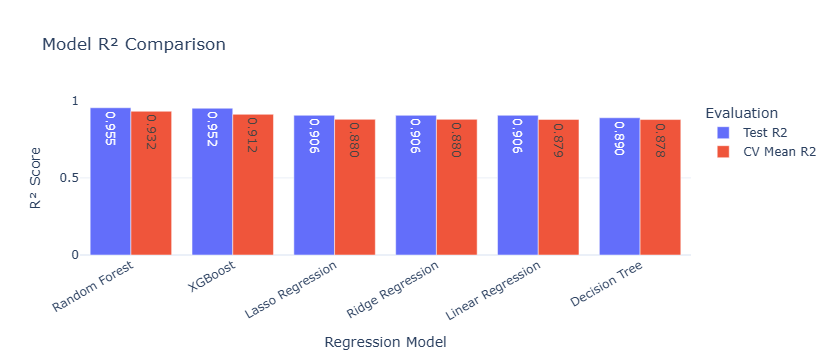

In [17]:
# ============================================================
# Test and Cross-Validation R² Comparison
# ============================================================

r2_plot_data = model_comparison[
    [
        "Model",
        "Test R2",
        "CV Mean R2"
    ]
].melt(
    id_vars="Model",
    var_name="Evaluation",
    value_name="R2"
)

fig = px.bar(
    r2_plot_data,
    x="Model",
    y="R2",
    color="Evaluation",
    barmode="group",
    text_auto=".3f",
    title="Model R² Comparison",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Regression Model",
    yaxis_title="R² Score",
    xaxis_tickangle=-30
)

fig.show()

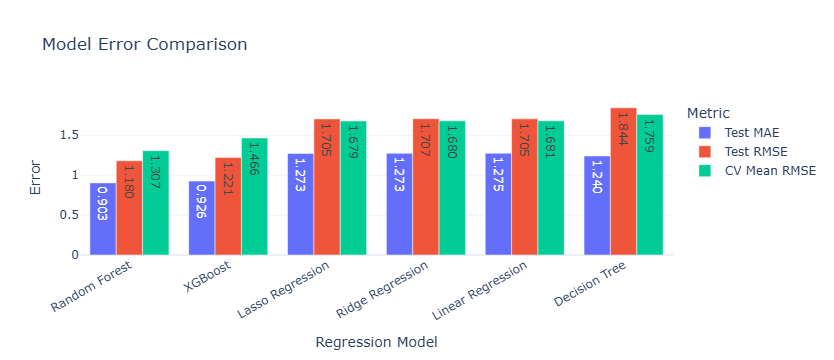

In [18]:
# ============================================================
# Model Error Comparison
# ============================================================

error_plot_data = model_comparison[
    [
        "Model",
        "Test MAE",
        "Test RMSE",
        "CV Mean RMSE"
    ]
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Error"
)

fig = px.bar(
    error_plot_data,
    x="Model",
    y="Error",
    color="Metric",
    barmode="group",
    text_auto=".3f",
    title="Model Error Comparison",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Regression Model",
    yaxis_title="Error",
    xaxis_tickangle=-30
)

fig.show()

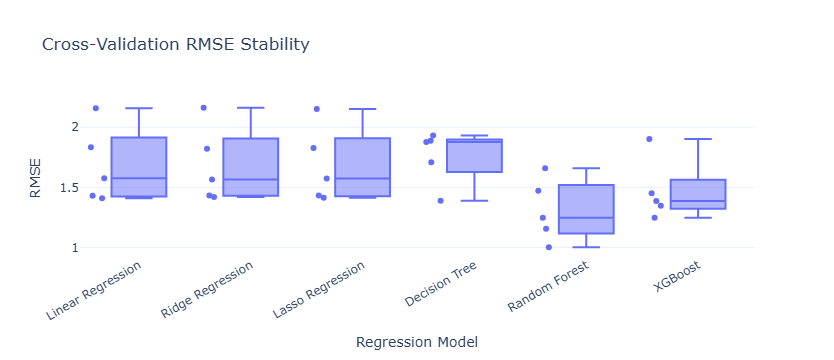

In [19]:
# ============================================================
# Cross-Validation RMSE by Fold
# ============================================================

fig = px.box(
    cross_validation_df,
    x="Model",
    y="RMSE",
    points="all",
    title="Cross-Validation RMSE Stability",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Regression Model",
    yaxis_title="RMSE",
    xaxis_tickangle=-30
)

fig.show()

In [20]:
# ============================================================
# Overfitting Summary
# ============================================================

overfitting_summary = model_comparison[
    [
        "Model",
        "Train R2",
        "Test R2",
        "R2 Gap",
        "CV Mean R2",
        "CV Mean RMSE"
    ]
].copy()

def classify_overfitting_gap(r2_gap):
    if r2_gap <= 0.05:
        return "Low"
    elif r2_gap <= 0.15:
        return "Moderate"
    else:
        return "High"

overfitting_summary[
    "Overfitting Risk"
] = overfitting_summary[
    "R2 Gap"
].apply(
    classify_overfitting_gap
)

display(
    overfitting_summary.style.format({
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "R2 Gap": "{:.4f}",
        "CV Mean R2": "{:.4f}",
        "CV Mean RMSE": "{:.4f}"
    })
)

,Model,Train R2,Test R2,R2 Gap,CV Mean R2,CV Mean RMSE,Overfitting Risk
0,Random Forest,0.9917,0.9549,0.0368,0.9321,1.3068,Low
1,XGBoost,0.9942,0.9517,0.0424,0.9124,1.4661,Low
2,Lasso Regression,0.9001,0.9059,-0.0058,0.8797,1.6789,Low
3,Ridge Regression,0.9001,0.9057,-0.0055,0.8796,1.6805,Low
4,Linear Regression,0.9001,0.9059,-0.0058,0.8793,1.6808,Low
5,Decision Tree,1.0000,0.8899,0.1101,0.8784,1.7587,Moderate


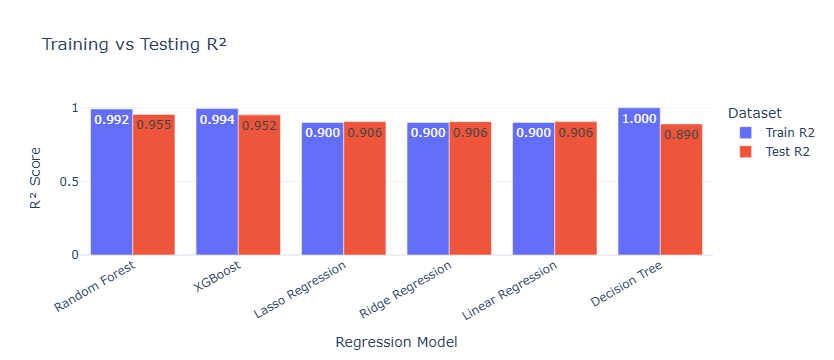

In [21]:
# ============================================================
# Training vs Testing R²
# ============================================================

train_test_r2_data = model_comparison[
    [
        "Model",
        "Train R2",
        "Test R2"
    ]
].melt(
    id_vars="Model",
    var_name="Dataset",
    value_name="R2"
)

fig = px.bar(
    train_test_r2_data,
    x="Model",
    y="R2",
    color="Dataset",
    barmode="group",
    text_auto=".3f",
    title="Training vs Testing R²",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Regression Model",
    yaxis_title="R² Score",
    xaxis_tickangle=-30
)

fig.show()

In [22]:
# ============================================================
# Convert Prediction Results to Long Format
# ============================================================

prediction_columns = [
    column
    for column in prediction_results.columns
    if column != "Actual_Sales"
]

prediction_long = prediction_results.melt(
    id_vars="Actual_Sales",
    value_vars=prediction_columns,
    var_name="Model",
    value_name="Predicted_Sales"
)

prediction_long["Model"] = (
    prediction_long["Model"]
    .str.replace(
        "_Prediction",
        "",
        regex=False
    )
    .str.replace(
        "_",
        " ",
        regex=False
    )
)

display(prediction_long.head())

,Actual_Sales,Model,Predicted_Sales
0,16.9,Linear Regression,17.034772
1,22.4,Linear Regression,20.409740
2,21.4,Linear Regression,23.723989
3,7.3,Linear Regression,9.272785
4,24.7,Linear Regression,21.682719


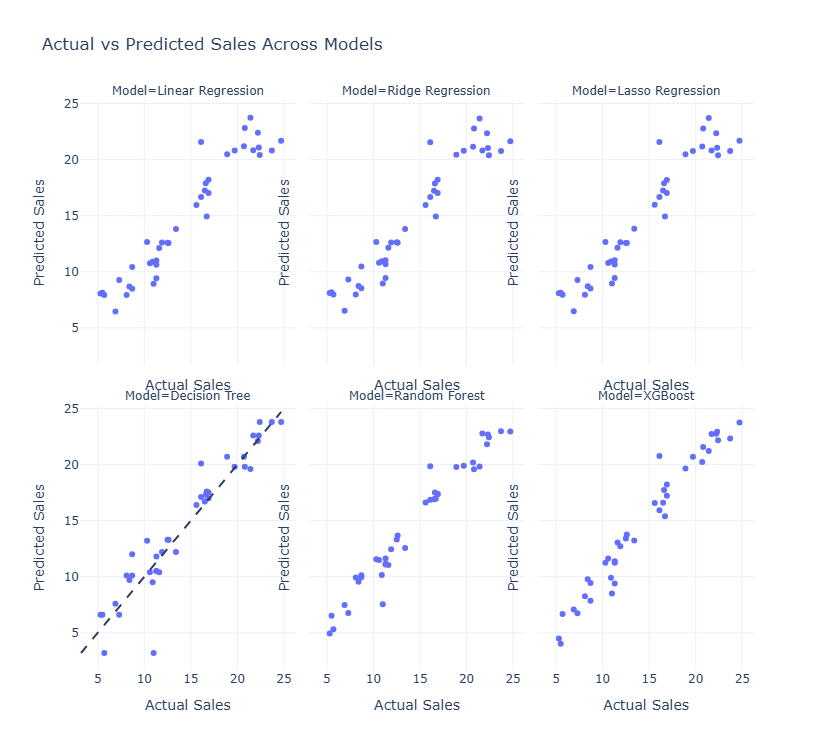

In [23]:
# ============================================================
# Actual vs Predicted Plot
# ============================================================

minimum_sales = min(
    prediction_long["Actual_Sales"].min(),
    prediction_long["Predicted_Sales"].min()
)

maximum_sales = max(
    prediction_long["Actual_Sales"].max(),
    prediction_long["Predicted_Sales"].max()
)

fig = px.scatter(
    prediction_long,
    x="Actual_Sales",
    y="Predicted_Sales",
    facet_col="Model",
    facet_col_wrap=3,
    title="Actual vs Predicted Sales Across Models",
    template="plotly_white"
)

fig.add_shape(
    type="line",
    x0=minimum_sales,
    y0=minimum_sales,
    x1=maximum_sales,
    y1=maximum_sales,
    line=dict(
        dash="dash"
    )
)

fig.update_layout(
    height=750
)

fig.for_each_xaxis(
    lambda axis: axis.update(
        title="Actual Sales"
    )
)

fig.for_each_yaxis(
    lambda axis: axis.update(
        title="Predicted Sales"
    )
)

fig.show()

In [24]:
# ============================================================
# Best Model Predictions
# ============================================================

best_prediction_column = (
    best_model_name
    .replace(" ", "_")
    + "_Prediction"
)

best_model_predictions = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": prediction_results[
        best_prediction_column
    ]
})

best_model_predictions["Residual"] = (
    best_model_predictions["Actual Sales"]
    - best_model_predictions["Predicted Sales"]
)

best_model_predictions["Absolute Error"] = (
    best_model_predictions["Residual"].abs()
)

display(
    best_model_predictions.head(10).style.format({
        "Actual Sales": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Residual": "{:.2f}",
        "Absolute Error": "{:.2f}"
    })
)

,Actual Sales,Predicted Sales,Residual,Absolute Error
0,16.90,17.37,-0.47,0.47
1,22.40,22.44,-0.04,0.04
2,21.40,19.83,1.57,1.57
3,7.30,6.78,0.52,0.52
4,24.70,22.95,1.75,1.75
5,12.60,13.67,-1.07,1.07
6,22.30,22.68,-0.38,0.38
7,8.40,9.56,-1.16,1.16
8,16.50,16.90,-0.40,0.40
9,16.10,16.86,-0.76,0.76


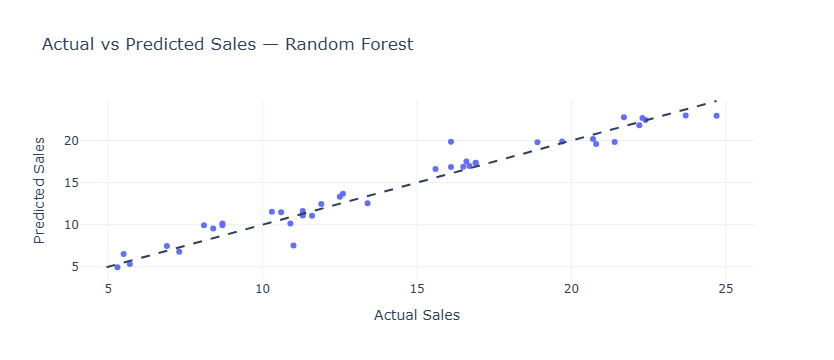

In [25]:
# ============================================================
# Best Model Actual vs Predicted
# ============================================================

plot_minimum = min(
    best_model_predictions[
        "Actual Sales"
    ].min(),
    best_model_predictions[
        "Predicted Sales"
    ].min()
)

plot_maximum = max(
    best_model_predictions[
        "Actual Sales"
    ].max(),
    best_model_predictions[
        "Predicted Sales"
    ].max()
)

fig = px.scatter(
    best_model_predictions,
    x="Actual Sales",
    y="Predicted Sales",
    hover_data=[
        "Residual",
        "Absolute Error"
    ],
    title=(
        f"Actual vs Predicted Sales — "
        f"{best_model_name}"
    ),
    template="plotly_white"
)

fig.add_shape(
    type="line",
    x0=plot_minimum,
    y0=plot_minimum,
    x1=plot_maximum,
    y1=plot_maximum,
    line=dict(
        dash="dash"
    )
)

fig.update_layout(
    xaxis_title="Actual Sales",
    yaxis_title="Predicted Sales"
)

fig.show()

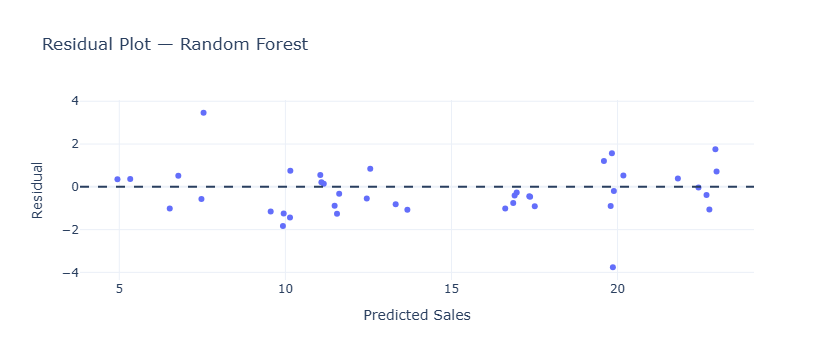

In [26]:
# ============================================================
# Residual Plot
# ============================================================

fig = px.scatter(
    best_model_predictions,
    x="Predicted Sales",
    y="Residual",
    hover_data=[
        "Actual Sales",
        "Absolute Error"
    ],
    title=f"Residual Plot — {best_model_name}",
    template="plotly_white"
)

fig.add_hline(
    y=0,
    line_dash="dash"
)

fig.update_layout(
    xaxis_title="Predicted Sales",
    yaxis_title="Residual"
)

fig.show()

In [27]:
# ============================================================
# Save Trained Models
# ============================================================

model_filename_map = {
    "Linear Regression": "linear_regression.pkl",
    "Ridge Regression": "ridge_regression.pkl",
    "Lasso Regression": "lasso_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "Random Forest": "random_forest.pkl",
    "XGBoost": "xgboost_model.pkl"
}

saved_model_records = []

for model_name, fitted_model in trained_models.items():

    filename = model_filename_map[
        model_name
    ]

    model_path = os.path.join(
        MODEL_DIR,
        filename
    )

    joblib.dump(
        fitted_model,
        model_path
    )

    saved_model_records.append({
        "Model": model_name,
        "File": filename,
        "Saved": os.path.exists(
            model_path
        )
    })

saved_models_df = pd.DataFrame(
    saved_model_records
)

display(saved_models_df)


,Model,File,Saved
0,Linear Regression,linear_regression.pkl,True
1,Ridge Regression,ridge_regression.pkl,True
2,Lasso Regression,lasso_regression.pkl,True
3,Decision Tree,decision_tree.pkl,True
4,Random Forest,random_forest.pkl,True
5,XGBoost,xgboost_model.pkl,True


In [28]:
# ============================================================
# Save Best Baseline Model
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_baseline_model.pkl"
)

joblib.dump(
    best_model,
    BEST_MODEL_PATH
)

print(
    "Best baseline model saved at:",
    BEST_MODEL_PATH
)

Best baseline model saved at: ../models\best_baseline_model.pkl


In [29]:
# ============================================================
# Save Model Metadata
# ============================================================

best_model_metadata = {
    "model_name": best_model_name,
    "feature_columns": X_train.columns.tolist(),
    "target_column": "Sales",
    "selection_metric": "CV Mean RMSE",
    "cv_mean_rmse": float(
        best_model_cv_rmse
    ),
    "test_rmse": float(
        best_model_test_rmse
    ),
    "test_r2": float(
        best_model_test_r2
    ),
    "random_state": RANDOM_STATE,
    "cross_validation_folds": 5
}

BEST_MODEL_METADATA_PATH = os.path.join(
    MODEL_DIR,
    "best_baseline_model_metadata.pkl"
)

joblib.dump(
    best_model_metadata,
    BEST_MODEL_METADATA_PATH
)

display(best_model_metadata)

{'model_name': 'Random Forest',
 'feature_columns': ['TV', 'Radio', 'Newspaper'],
 'target_column': 'Sales',
 'selection_metric': 'CV Mean RMSE',
 'cv_mean_rmse': 1.3068446202344741,
 'test_rmse': 1.1800651853464104,
 'test_r2': 0.9549351368829375,
 'random_state': 42,
 'cross_validation_folds': 5}

In [30]:
# ============================================================
# Save Model Comparison Report
# ============================================================

MODEL_METRICS_PATH = os.path.join(
    REPORT_DIR,
    "model_metrics.csv"
)

model_comparison.to_csv(
    MODEL_METRICS_PATH,
    index=False
)

print(
    "Model metrics saved at:",
    MODEL_METRICS_PATH
)

Model metrics saved at: ../reports\model_metrics.csv


In [31]:
# ============================================================
# Save Cross-Validation Results
# ============================================================

CV_RESULTS_PATH = os.path.join(
    REPORT_DIR,
    "cross_validation_results.csv"
)

cross_validation_df.to_csv(
    CV_RESULTS_PATH,
    index=False
)

print(
    "Cross-validation results saved at:",
    CV_RESULTS_PATH
)

Cross-validation results saved at: ../reports\cross_validation_results.csv


In [32]:
# ============================================================
# Save Prediction Results
# ============================================================

PREDICTIONS_PATH = os.path.join(
    REPORT_DIR,
    "model_predictions.csv"
)

prediction_results.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(
    "Predictions saved at:",
    PREDICTIONS_PATH
)

Predictions saved at: ../reports\model_predictions.csv


In [33]:
# ============================================================
# Save Best Model Prediction Analysis
# ============================================================

BEST_PREDICTIONS_PATH = os.path.join(
    REPORT_DIR,
    "best_model_predictions.csv"
)

best_model_predictions.to_csv(
    BEST_PREDICTIONS_PATH,
    index=False
)

print(
    "Best model predictions saved at:",
    BEST_PREDICTIONS_PATH
)

Best model predictions saved at: ../reports\best_model_predictions.csv


In [34]:
# ============================================================
# Reload Best Baseline Model
# ============================================================

reloaded_best_model = joblib.load(
    BEST_MODEL_PATH
)

reloaded_predictions = (
    reloaded_best_model.predict(
        X_test
    )
)

original_predictions = (
    best_model.predict(
        X_test
    )
)

assert np.allclose(
    reloaded_predictions,
    original_predictions
), (
    "Reloaded model predictions do not match "
    "the original model predictions."
)

print(
    "Best baseline model was reloaded "
    "and validated successfully."
)

Best baseline model was reloaded and validated successfully.


In [35]:
# ============================================================
# Verify Expected Output Files
# ============================================================

expected_output_files = [
    os.path.join(
        MODEL_DIR,
        "best_baseline_model.pkl"
    ),
    os.path.join(
        MODEL_DIR,
        "best_baseline_model_metadata.pkl"
    ),
    os.path.join(
        REPORT_DIR,
        "model_metrics.csv"
    ),
    os.path.join(
        REPORT_DIR,
        "cross_validation_results.csv"
    ),
    os.path.join(
        REPORT_DIR,
        "model_predictions.csv"
    ),
    os.path.join(
        REPORT_DIR,
        "best_model_predictions.csv"
    )
]

output_file_verification = pd.DataFrame({
    "File": [
        os.path.basename(path)
        for path in expected_output_files
    ],
    "Saved": [
        os.path.exists(path)
        for path in expected_output_files
    ]
})

display(output_file_verification)

,File,Saved
0,best_baseline_model.pkl,True
1,best_baseline_model_metadata.pkl,True
2,model_metrics.csv,True
3,cross_validation_results.csv,True
4,model_predictions.csv,True
5,best_model_predictions.csv,True


In [36]:
# ============================================================
# Modeling Summary
# ============================================================

modeling_summary = pd.DataFrame({
    "Item": [
        "Models evaluated",
        "Cross-validation folds",
        "Primary selection metric",
        "Best baseline model",
        "Best CV RMSE",
        "Best test RMSE",
        "Best test R²",
        "All models saved",
        "Evaluation reports saved",
        "Reload validation completed"
    ],
    "Value": [
        len(models),
        5,
        "CV Mean RMSE",
        best_model_name,
        round(
            best_model_cv_rmse,
            4
        ),
        round(
            best_model_test_rmse,
            4
        ),
        round(
            best_model_test_r2,
            4
        ),
        saved_models_df[
            "Saved"
        ].all(),
        True,
        True
    ]
})

display(modeling_summary)

,Item,Value
0,Models evaluated,6
1,Cross-validation folds,5
2,Primary selection metric,CV Mean RMSE
3,Best baseline model,Random Forest
4,Best CV RMSE,1.3068
5,Best test RMSE,1.1801
6,Best test R²,0.9549
7,All models saved,True
8,Evaluation reports saved,True
9,Reload validation completed,True
